In [107]:
import json
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates
from matplotlib.ticker import FixedLocator


In [121]:
def read_json_file(file_path):
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)
        return data
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
        return None
    except json.JSONDecodeError:
        print(f"Error: Invalid JSON format in '{file_path}'.")
        return None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None



def set_datetime_ticks(ax,major=8,minor_every=3):
    """
    Simple function to set datetime ticks:
    - Major ticks at 8AM daily
    - Minor ticks every 3 hours
    """
    from matplotlib.ticker import FixedLocator
    from datetime import timedelta
    
    # Get current limits
    xlim = ax.get_xlim()
    start_date = mdates.num2date(xlim[0]).replace(hour=major, minute=0, second=0, microsecond=0)
    end_date = mdates.num2date(xlim[1])
    
    # Generate 8AM major ticks
    major_ticks = []
    current = start_date
    while current <= end_date:
        major_ticks.append(mdates.date2num(current))
        current += timedelta(days=1)
    
    # Generate minor ticks (every 3 hours after each 8AM)
    minor_ticks = []
    current = start_date
    while current <= end_date:
        # Add 3-hour intervals: 11AM, 2PM, 5PM
        for hours_offset in range(minor_every,25,minor_every):
            minor_tick = current + timedelta(hours=hours_offset)
            if minor_tick <= end_date:
                minor_ticks.append(mdates.date2num(minor_tick))
        current += timedelta(days=1)
    
    # Set the ticks
    ax.xaxis.set_major_locator(FixedLocator(major_ticks))
    ax.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d\n8AM'))


# HEAVY RAINFALL OUTLOOK FUNCTIONS

In [137]:
def extract_all_unique_areas(data):
    """
    Extract all unique areas from nested weather advisory data structure.
    
    Args:
        data: Dictionary with structure:
              {timestamp: {tables: {table_id: {forecast_periods: {period_x: {rainfall_categories: {category: [areas]}}}}}}}
    
    Returns:
        set: All unique areas found across all timestamps, tables, periods, and categories
    """
    unique_areas = set()
    
    # Iterate through all timestamps
    for ts in data.keys():
        # Check if 'tables' exists in this timestamp
        if 'tables' not in data[ts]:
            continue
            
        # Iterate through all tables
        for table_id in data[ts]['tables'].keys():
            table_data = data[ts]['tables'][table_id]
            
            # Check if 'forecast_periods' exists in this table
            if 'forecast_periods' not in table_data:
                continue
                
            # Iterate through all forecast periods
            for period_key in table_data['forecast_periods'].keys():
                if not period_key.startswith('period_'):
                    continue
                    
                period_data = table_data['forecast_periods'][period_key]
                
                # Check if 'rainfall_categories' exists in this period
                if 'rainfall_categories' not in period_data:
                    continue
                    
                # Iterate through all rainfall categories
                for category in period_data['rainfall_categories'].keys():
                    areas_list = period_data['rainfall_categories'][category]
                    
                    # Add areas to the set (handles both lists and individual items)
                    if isinstance(areas_list, list):
                        unique_areas.update(areas_list)
                    else:
                        unique_areas.add(areas_list)
    
    return unique_areas


def extract_area_records(data, target_area, fill_missing=True):
    """
    Extract records for a specific area across all timestamps and periods.
    
    Args:
        data: Dictionary with nested weather advisory structure
        target_area: String name of the area to search for
        fill_missing: Boolean, if True fills Case #2 (area not mentioned in existing timestamps)
                     Note: Case #1 (missing timestamps from entire dataset) cannot be detected
    
    Returns:
        dict: {timestamp: {advisory_id: id, period_1: rainfall_category or None, period_2: ..., period_3: ...}}
    """
    area_records = {}
    
    # First pass: Extract records where area is found
    for ts in data.keys():
        if 'tables' not in data[ts]:
            continue
            
        # Extract advisory ID (assuming it's stored at the top level of each timestamp)
        advisory_id = data[ts].get('advisory_id', ts)  # Fallback to timestamp if no advisory_id
        
        # Initialize periods for this timestamp
        periods_data = {
            'advisory_id': advisory_id,
            'period_1': None,
            'period_2': None,
            'period_3': None
        }
        
        found_in_timestamp = False
        
        # Search through all tables for this timestamp
        for table_id in data[ts]['tables'].keys():
            table_data = data[ts]['tables'][table_id]
            
            if 'forecast_periods' not in table_data:
                continue
                
            # Check each period (period_1, period_2, period_3)
            for period_num in range(1, 4):  # periods 1, 2, 3
                period_key = f'period_{period_num}'
                
                if period_key not in table_data['forecast_periods']:
                    continue
                    
                period_data = table_data['forecast_periods'][period_key]
                
                if 'rainfall_categories' not in period_data:
                    continue
                    
                # Search through all rainfall categories in this period
                for category, areas_list in period_data['rainfall_categories'].items():
                    # Check if target_area is in this category
                    area_found = False
                    if isinstance(areas_list, list):
                        area_found = target_area in areas_list
                    else:
                        area_found = target_area == areas_list
                    
                    if area_found:
                        periods_data[period_key] = category
                        found_in_timestamp = True
                        break  # Found in this period, move to next period
        
        # Add timestamp to results if area was found
        if found_in_timestamp:
            area_records[ts] = periods_data
    
    # Second pass: Fill Case #2 (area not mentioned in existing timestamps) if requested
    if fill_missing and area_records:
        area_records = fill_missing_records(data, area_records, target_area)
    
    return area_records

def fill_missing_records(data, area_records, target_area):
    """
    Fill missing mentions of an area between its earliest and latest appearances.
    
    Note: This only handles Case #2 (area not mentioned in existing timestamps).
    Case #1 (missing timestamps from entire dataset) cannot be detected.
    
    Args:
        data: Original data dictionary
        area_records: Existing area records with found mentions
        target_area: Area name being processed
    
    Returns:
        dict: Updated area_records with missing area mentions filled
    """
    if not area_records:
        return area_records
    
    # Find earliest and latest timestamps where area was found
    timestamps = list(area_records.keys())
    earliest_ts = min(timestamps)
    latest_ts = max(timestamps)
    
    # Get all timestamps that exist in the data and sort them
    all_timestamps = sorted([ts for ts in data.keys() if 'tables' in data[ts]])
    
    # Find the range of timestamps between earliest and latest area mentions
    try:
        start_idx = all_timestamps.index(earliest_ts)
        end_idx = all_timestamps.index(latest_ts)
    except ValueError:
        # If timestamps not found in sorted list, return original records
        return area_records
    
    # Fill missing area mentions in existing timestamps between first and last mention
    for ts in all_timestamps[start_idx:end_idx + 1]:
        if ts not in area_records:
            # This timestamp exists in data but area was not mentioned
            # Get advisory ID for this timestamp
            advisory_id = data[ts].get('advisory_id', ts)
            
            # Create record with all None periods (area not mentioned in this advisory)
            area_records[ts] = {
                'advisory_id': advisory_id,
                'period_1': None,
                'period_2': None,
                'period_3': None
            }
    
    return area_records


def process_area_records_for_plotting(area_records, area_name):
    """
    Convert area records to a format optimized for timeline plotting.
    
    Args:
        area_records: Dict from extract_area_records() for a specific area
        area_name: String name of the area
    
    Returns:
        list: List of dictionaries, each representing a line segment:
              [{'area': str, 'advisory_id': int, 'advisory_id_original': str, 'timestamp': str, 'period': str, 'category': str, 
                'start_time': datetime, 'end_time': datetime, 'duration_hours': int}]
    """
    plot_segments = []
    
    for timestamp, periods in area_records.items():
        # Parse timestamp
        try:
            base_time = datetime.fromisoformat(timestamp.replace('Z', '+00:00'))
        except:
            # Fallback for different timestamp formats
            base_time = pd.to_datetime(timestamp)
        
        # Extract advisory ID and convert to integer if possible
        advisory_id = periods.get('advisory_id', timestamp)
        
        # Try to extract numeric part from advisory ID
        try:
            if isinstance(advisory_id, str):
                # Extract numbers from advisory ID (e.g., "ADV001" -> 1, "Advisory_123" -> 123)
                import re
                numeric_match = re.search(r'\d+', advisory_id)
                if numeric_match:
                    advisory_id_int = int(numeric_match.group())
                else:
                    # If no numbers found, use hash of string as fallback
                    advisory_id_int = abs(hash(advisory_id)) % 10000
            else:
                advisory_id_int = int(advisory_id)
        except (ValueError, TypeError):
            # Fallback: use hash of the advisory_id string
            advisory_id_int = abs(hash(str(advisory_id))) % 10000
        
        # Process each period (excluding advisory_id key)
        for period_key, category in periods.items():
            if period_key == 'advisory_id':  # Skip the advisory_id key
                continue
                
            # Calculate start and end times
            period_num = int(period_key.split('_')[1])  # Extract number from period_1, period_2, etc.
            start_offset_hours = (period_num - 1) * 24
            
            start_time = base_time + timedelta(hours=start_offset_hours)
            end_time = start_time + timedelta(hours=24)
            
            plot_segments.append({
                'area': area_name,
                'advisory_id': advisory_id_int,  # Now an integer
                'advisory_id_original': advisory_id,  # Keep original for reference
                'timestamp': timestamp,
                'period': period_key,
                'category': category,
                'start_time': start_time,
                'end_time': end_time,
                'duration_hours': 24
            })
    
    return plot_segments

def create_rainfall_color_map():
    """
    Create a color mapping for different rainfall categories.
    
    Returns:
        dict: Mapping of rainfall categories to colors
    """
    color_map = {
        # Red for >200mm
        'above_200mm': '#FF0000',        # Red (alternative naming)
        
        # Orange for 100-200mm range  
        '100_to_200mm': '#FF8C00',       # Dark Orange
        
        # Yellow for 50-100mm range
        '50_to_100mm': '#FFD700',        # Gold/Yellow
        
        # # Light colors for lower ranges (if they exist)
        # '5_to_15mm': '#E6F3FF',          # Very light blue
        # '15_to_30mm': '#CCE7FF',         # Light blue  
        # '30_to_60mm': '#99D6FF',         # Medium light blue
        # '60_to_120mm': '#66C2FF',        # Medium blue
        
        # Gray for None values
        None: '#808080'                   # Gray
    }
    return color_map

def plot_hro_timeline(plot_segments, area_filter=None, period_filter=None, figsize=(15, 10),linewidth=8):
    """
    Create a timeline plot showing rainfall periods for different advisories.
    
    Args:
        plot_segments: List of dictionaries from process_area_records_for_plotting()
        area_filter: List of area names to include (None for all areas)
        period_filter: List of periods to include, e.g., ['period_1', 'period_3'] (None for all periods)
        figsize: Tuple for figure size
    
    Returns:
        matplotlib figure and axes objects
    """
    # Convert to DataFrame for easier filtering if needed
    plot_data = pd.DataFrame(plot_segments)
    
    if area_filter and not plot_data.empty:
        plot_data = plot_data[plot_data['area'].isin(area_filter)]
    
    if period_filter and not plot_data.empty:
        plot_data = plot_data[plot_data['period'].isin(period_filter)]
    
    color_map = create_rainfall_color_map()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot each segment as a horizontal line with endpoint markers
    for _, row in plot_data.iterrows():
        y_pos = row['advisory_id']  # Now directly use integer advisory_id
        color = color_map.get(row['category'], '#808080')  # Use gray as default
        
        # Create line segment
        ax.plot([row['start_time'], row['end_time']], [y_pos, y_pos], 
                color=color, linewidth=linewidth, solid_capstyle='butt')
        
        # Add black dots at endpoints
        ax.plot(row['start_time'], y_pos, 'k|', markersize=4)  # Start point
        ax.plot(row['end_time'], y_pos, 'k|', markersize=4)    # End point

    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(axis='y',ls=':')
    
    
    # Create custom legend
    legend_elements = []
    
    # Add rainfall category legend items
    if not plot_data.empty:
        present_categories = set(plot_data['category'].values)
        for category, color in color_map.items():
            if category in present_categories:
                label = category.replace("_"," ").replace("mm","") if category else 'below 50'
                legend_elements.append(plt.Line2D([0], [0], color=color, lw=4, label=label))
    
    ax.legend(title='1-day forecast rain (mm)',handles=legend_elements, bbox_to_anchor=(0.75, 1), loc='upper left')
    ax.invert_yaxis()
    
    plt.tight_layout()
    return fig, ax

def create_hro_analysis(series_json_path,figsize=(9,5)):
    # extract advisory series json data
    data = read_json_file(series_json_path)
    # show all areas covered
    unique_areas=list(extract_all_unique_areas(data))
    unique_areas.sort()
    unique_area_dict={i:unique_areas[i] for i in range(len(unique_areas))}
    print(unique_area_dict)
    which_place=unique_area_dict[int(input("Type number of area to analyze: "))]
    area_records=extract_area_records(data, which_place)
    hro_segments=process_area_records_for_plotting(area_records, which_place)
    plt.close("all")
    fig,ax=plot_hro_timeline(hro_segments, area_filter=None, figsize=figsize,linewidth=8)#,period_filter=['period_1'])
    # Customize plot - y-axis now uses integer values
    ax.set_xlabel('Time')
    ax.set_ylabel('Advisory ID')
    set_datetime_ticks(ax,major=8,minor_every=6)
    ax.grid(axis='x',which='major',ls=':')
    # Rotate x-axis labels for better readability
    # plt.xticks(rotation=45)
    

# MAIN

{0: 'Abra', 1: 'Aklan', 2: 'Albay', 3: 'Antique', 4: 'Apayao', 5: 'Aurora', 6: 'Bataan', 7: 'Batanes', 8: 'Batangas', 9: 'Benguet', 10: 'Biliran', 11: 'Bulacan', 12: 'Cagayan', 13: 'Camarines Norte', 14: 'Camarines Sur', 15: 'Capiz', 16: 'Capiz Iloilo', 17: 'Catanduanes', 18: 'Cavite', 19: 'Cebu', 20: 'Eastern Samar', 21: 'Guimaras', 22: 'Ifugao', 23: 'Ilocos Norte', 24: 'Ilocos Sur', 25: 'Ilocos Sur La Union', 26: 'Iloilo', 27: 'Isabela', 28: 'Kalinga', 29: 'La Union', 30: 'Laguna', 31: 'Lanao del Norte', 32: 'Lanao del Sur', 33: 'Maguindanao del Norte', 34: 'Mariduque', 35: 'Marinduque', 36: 'Masbate', 37: 'Metro Manila', 38: 'Mountain Province', 39: 'Negros Occidental', 40: 'Negros Oriental', 41: 'Northern Samar', 42: 'Nueva Ecija', 43: 'Nueva EcijaQuezon', 44: 'Nueva Vizcaya', 45: 'Occidental Mindoro', 46: 'Oriental Mindoro', 47: 'Palawan', 48: 'Pampanga', 49: 'Pangasinan', 50: 'Quezon', 51: 'Quezon Laguna', 52: 'Quirino', 53: 'Rizal', 54: 'Romblon', 55: 'Samar', 56: 'Siquijor', 57

Type number of area to analyze:  37


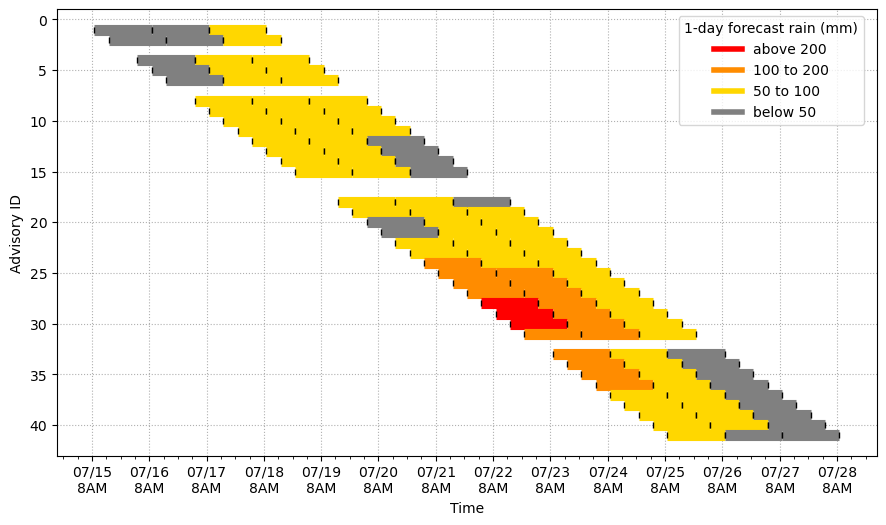

In [139]:
create_hro_analysis('hro-jsons/pagasa-hro-2025-07-15.json')

